In [1]:
import sys
from pathlib import Path
prediction_mode_path = Path("./module")
sys.path.append(prediction_mode_path.as_posix())
import models_creation as pred_model

import pandas as pd
import numpy as np

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from sklearn.model_selection import train_test_split
import math

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
#from sklearn import tree

from matplotlib import pyplot as plt

import joblib

from mordred import Calculator, descriptors
import mordred
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem import Draw

import warnings
warnings.filterwarnings('ignore')

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [2]:
molecular_descriptors_df_I = pred_model.prepare_data('QSPR_epoxidation_model_I.xlsx')

100%|██████████████████████████████████████████████████████████████████████████████████| 41/41 [00:01<00:00, 26.41it/s]


Data size (rows, columns): (41, 3874)
Data size after second reduction (rows, columns): (41, 3874)


In [3]:
molecular_descriptors_df_II = pred_model.prepare_data('QSPR_epoxidation_model_II.xlsx')

100%|██████████████████████████████████████████████████████████████████████████████████| 67/67 [00:01<00:00, 36.77it/s]


Data size (rows, columns): (67, 3874)
Data size after second reduction (rows, columns): (67, 3874)


In [4]:
molecular_descriptors_df_III = pred_model.prepare_data('QSPR_epoxidation_model_III.xlsx')

 24%|███████████████████▊                                                              | 15/62 [00:01<00:05,  8.52it/s]

C:\Users\aleks\anaconda3\envs\cheminf_gpu\lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\aleks\anaconda3\envs\cheminf_gpu\lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\aleks\anaconda3\envs\cheminf_gpu\lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\aleks\anaconda3\envs\cheminf_gpu\lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\aleks\anaconda3\envs\cheminf_gpu\lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\aleks\anaco

 69%|████████████████████████████████████████████████████████▊                         | 43/62 [00:01<00:00, 50.38it/s]

C:\Users\aleks\anaconda3\envs\cheminf_gpu\lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\aleks\anaconda3\envs\cheminf_gpu\lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\aleks\anaconda3\envs\cheminf_gpu\lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\aleks\anaconda3\envs\cheminf_gpu\lib\site-packages\numpy\core\fromnumeric.py:88: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


100%|██████████████████████████████████████████████████████████████████████████████████| 62/62 [00:01<00:00, 36.09it/s]


Data size (rows, columns): (62, 3874)
Data size after second reduction (rows, columns): (62, 3874)


Data size after first reduction (rows, columns): (170, 3122)


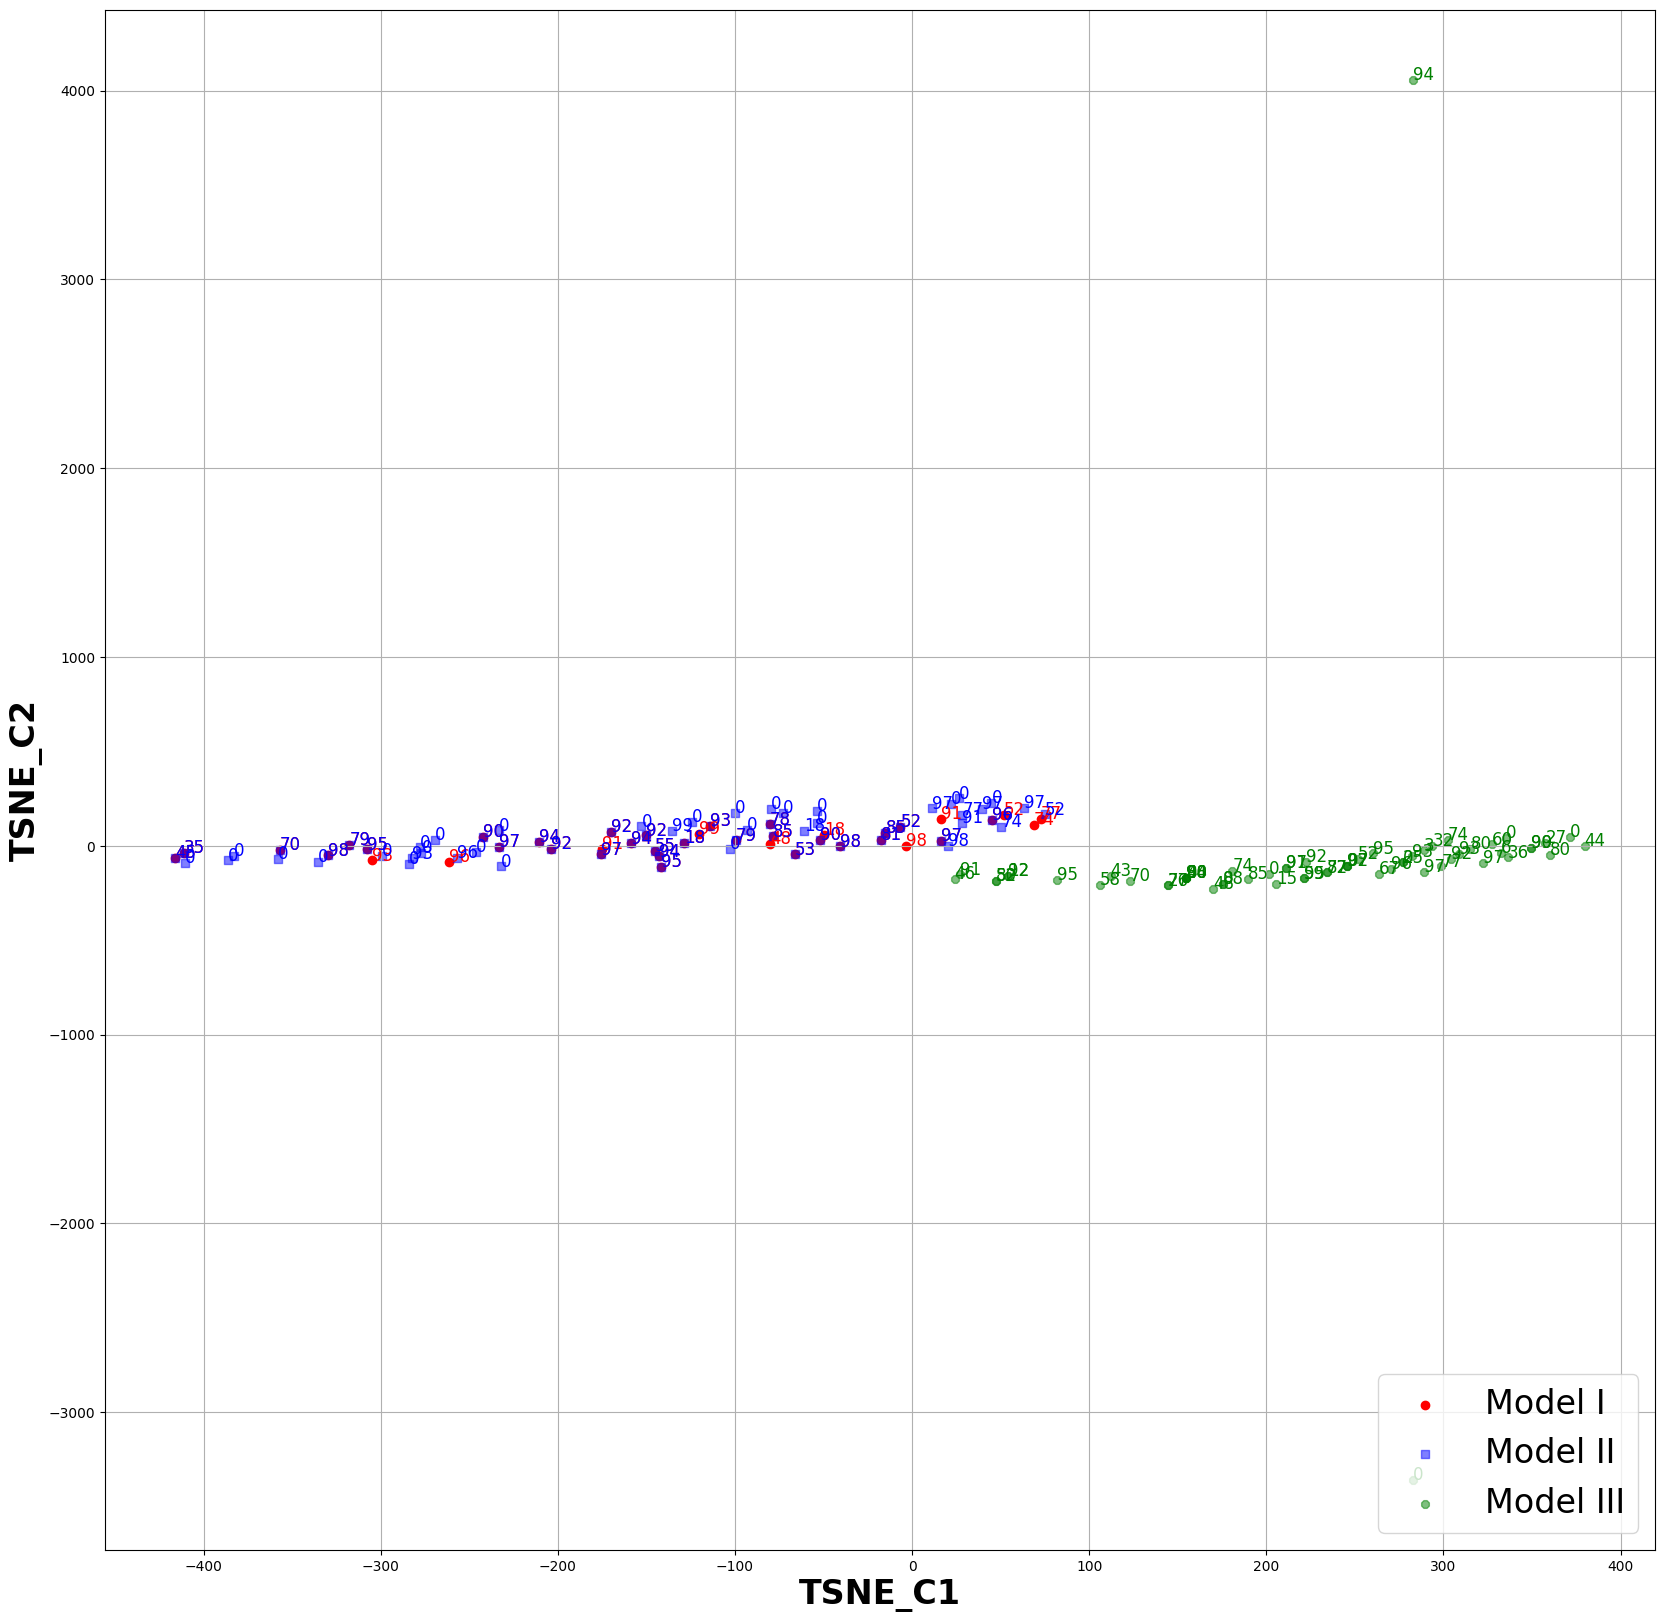

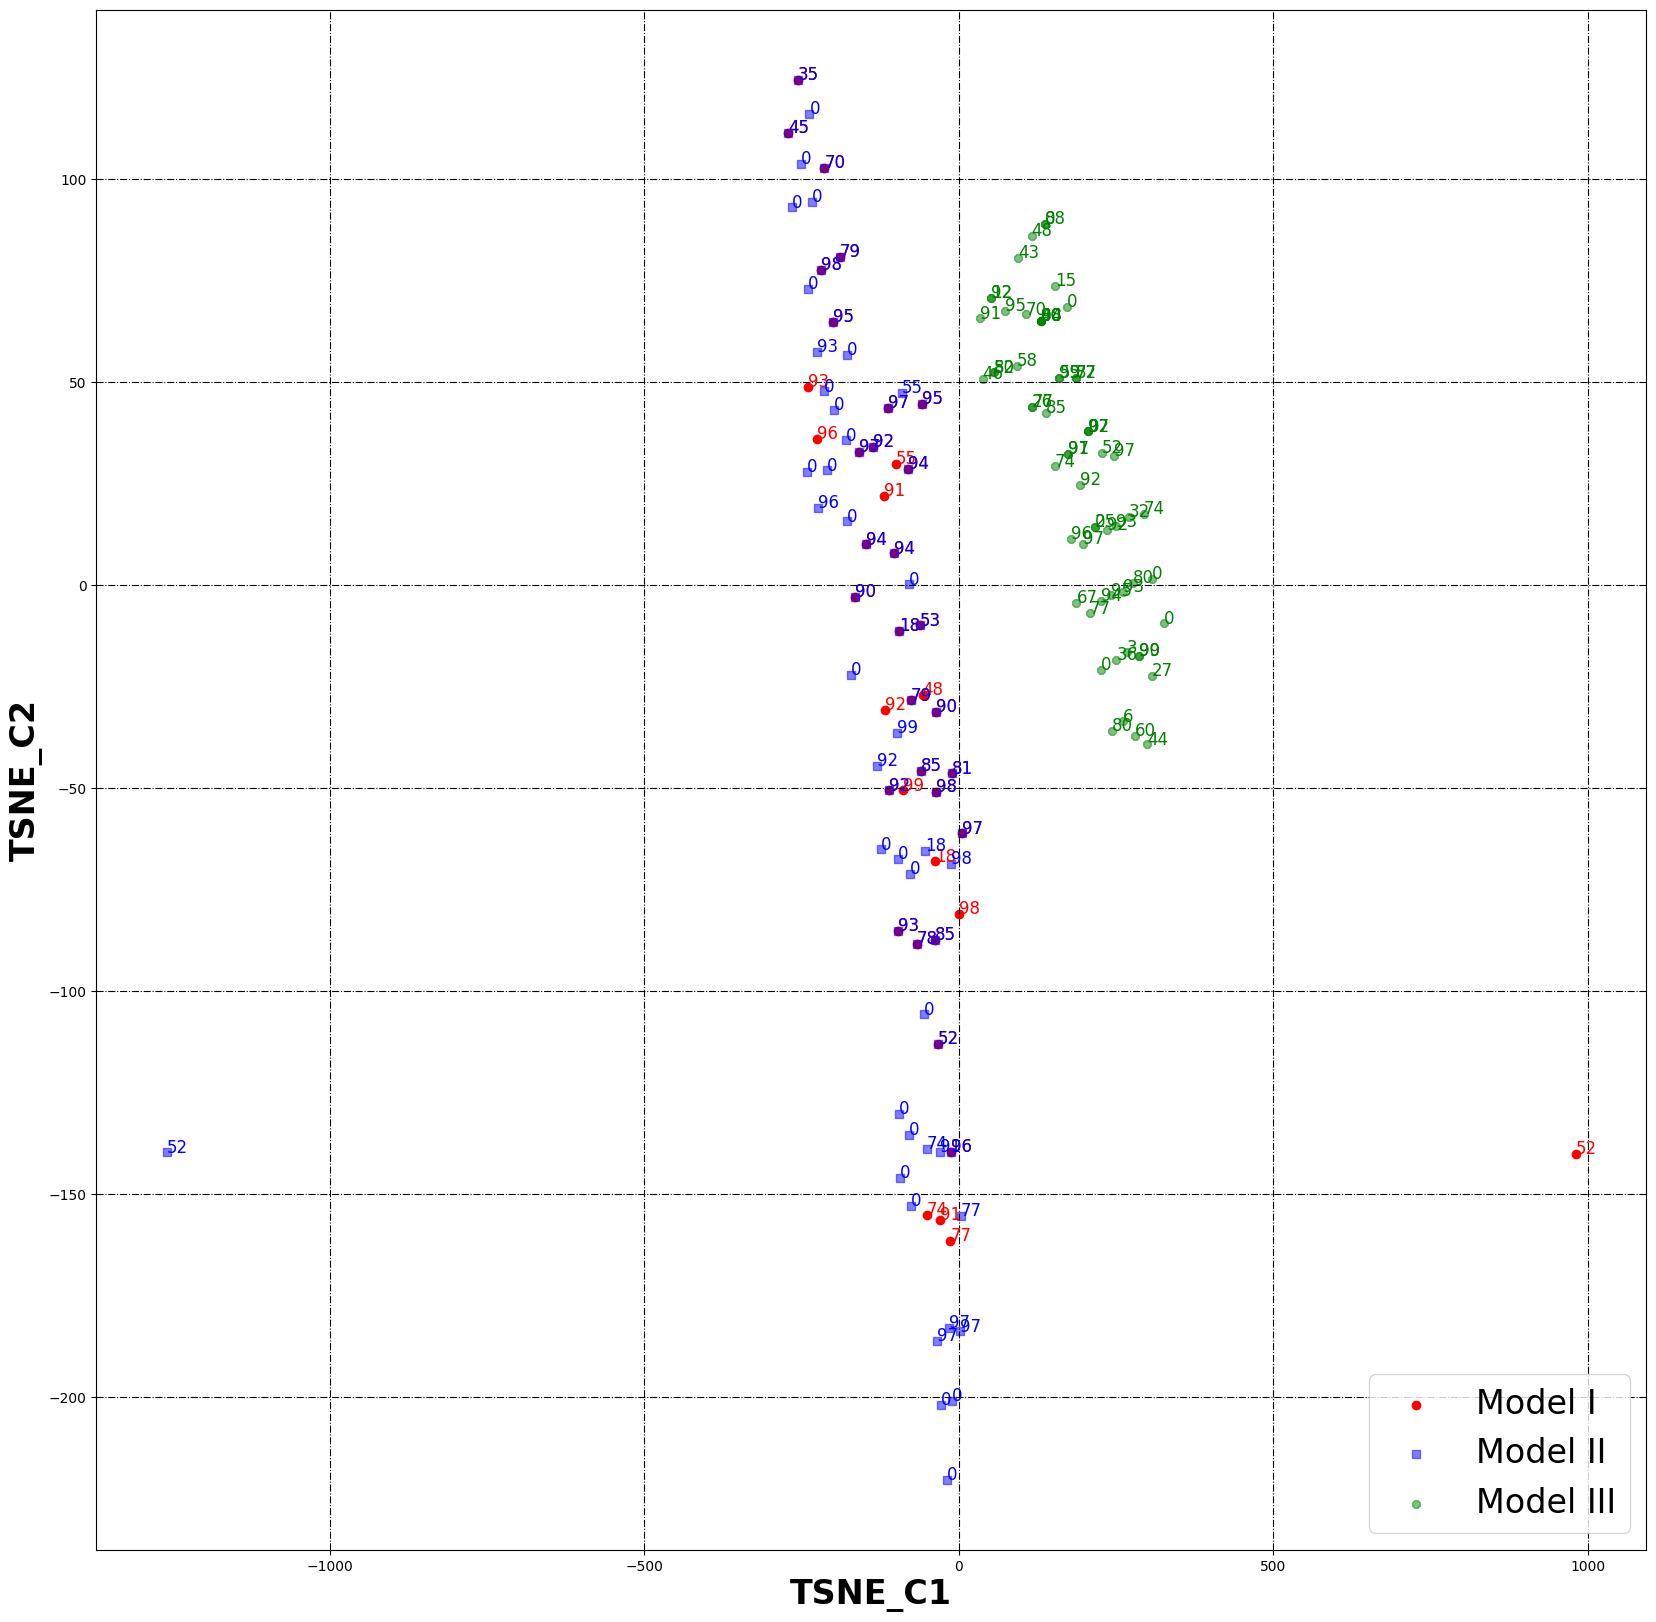

In [5]:

#First model
model_I = molecular_descriptors_df_I
model_I['Model'] = 'Model I'

model_II = molecular_descriptors_df_II
model_II['Model'] = 'Model II'

model_III = molecular_descriptors_df_III
model_III['Model'] = 'Model III'

# Concatenate DataFrames
whole_df = pd.concat([model_I, model_II, model_III], ignore_index=True)

simple_preprocessing = True #True
if simple_preprocessing:
    whole_df = whole_df.dropna(axis=1, how='any')
    print("Data size after first reduction (rows, columns): " + str(whole_df.shape))
        
whole_df_ = whole_df['ee'].copy()
whole_df__df = pd.DataFrame(data=whole_df_, columns=['ee'])
whole_df__ = whole_df.copy()

# t-SNE analysis
model = TSNE(n_components=2, random_state=0, perplexity=30, n_iter=5000, init='pca')
tsne_whole_set = model.fit_transform(whole_df.iloc[:,:-2])

whole_df['TSNE_C1'] = tsne_whole_set.T[0]
whole_df['TSNE_C2'] = tsne_whole_set.T[1]

test = whole_df.copy()

        
x_model_I = whole_df.loc[whole_df['Model'] == 'Model I']
x_model_II = whole_df.loc[whole_df['Model'] == 'Model II']
x_model_III = whole_df.loc[whole_df['Model'] == 'Model III']

fig = plt.figure(figsize=(20,20))
ax = fig.add_subplot(111)

ax.scatter(x_model_I['TSNE_C1'], x_model_I['TSNE_C2'], c='r', marker="o", label='Model I') #, alpha=1
ax.scatter(x_model_II['TSNE_C1'], x_model_II['TSNE_C2'], c='b', marker="s", label='Model II', alpha=0.5)#, alpha=0.1
ax.scatter(x_model_III['TSNE_C1'], x_model_III['TSNE_C2'], c='g', marker="8", label='Model III', alpha=0.5)#, alpha=0.1

for i, txt in enumerate(x_model_I.index):
    ax.annotate(int(whole_df__df['ee'][i]), (x_model_I['TSNE_C1'][i], x_model_I['TSNE_C2'][i]), fontsize=12, color='red')

for i, txt in enumerate(x_model_II.index):
    ax.annotate(int(whole_df__df['ee'][i+41]), (x_model_II['TSNE_C1'][i+41], x_model_II['TSNE_C2'][i+41]), fontsize=12, color='blue')

for i, txt in enumerate(x_model_III.index):
    ax.annotate(int(whole_df__df['ee'][i+108]), (x_model_III['TSNE_C1'][i+108], x_model_III['TSNE_C2'][i+108]), fontsize=12, color='green')
    
plt.legend(loc='lower right', fontsize=24)
plt.xlabel('TSNE_C1', fontweight='bold', fontsize=24)
plt.ylabel('TSNE_C2', fontweight='bold', fontsize=24)
plt.rc('grid', linestyle="-.", color='black')
plt.grid(True)
plt.savefig('t-SNE_analysis_'+'_WHOLE_I_II_III'+'.svg', bbox_inches='tight')
        
# PCA analysis
pca = PCA(n_components=5, random_state=42) #n_components=20 in the case of activity_pred_app
pca_training_whole = pca.fit_transform(whole_df__.iloc[:,:-2])

list_pca = []
whole_data_II = pd.DataFrame(data=whole_df_, columns=['ee'])
for i in range(5):
    list_pca.append('PC'+str(i+1))
for pca_ in range(5):
    whole_data_II[list_pca[pca_]] = pca_training_whole.T[pca_]

        # t-SNE analysis
model = TSNE(n_components=2, random_state=0, perplexity=30, n_iter=5000, init='pca')
tsne_whole_set = model.fit_transform(pca_training_whole)

tsne_whole_set_PCA = tsne_whole_set.copy()

whole_df['TSNE_C1'] = tsne_whole_set.T[0]
whole_df['TSNE_C2'] = tsne_whole_set.T[1]

x_model_I = whole_df.loc[whole_df['Model'] == 'Model I']
x_model_II = whole_df.loc[whole_df['Model'] == 'Model II']
x_model_III = whole_df.loc[whole_df['Model'] == 'Model III']

fig = plt.figure(figsize=(20,20))
ax = fig.add_subplot(111)

ax.scatter(x_model_I['TSNE_C1'], x_model_I['TSNE_C2'], c='r', marker="o", label='Model I') #, alpha=1
ax.scatter(x_model_II['TSNE_C1'], x_model_II['TSNE_C2'], c='b', marker="s", label='Model II', alpha=0.5)#, alpha=0.1
ax.scatter(x_model_III['TSNE_C1'], x_model_III['TSNE_C2'], c='g', marker="8", label='Model III', alpha=0.5)#, alpha=0.1

for i, txt in enumerate(x_model_I.index):
    ax.annotate(int(whole_df__df['ee'][i]), (x_model_I['TSNE_C1'][i], x_model_I['TSNE_C2'][i]), fontsize=12, color='red')

for i, txt in enumerate(x_model_II.index):
    ax.annotate(int(whole_df__df['ee'][i+41]), (x_model_II['TSNE_C1'][i+41], x_model_II['TSNE_C2'][i+41]), fontsize=12, color='blue')

for i, txt in enumerate(x_model_III.index):
    ax.annotate(int(whole_df__df['ee'][i+108]), (x_model_III['TSNE_C1'][i+108], x_model_III['TSNE_C2'][i+108]), fontsize=12, color='green')
    
plt.legend(loc='lower right', fontsize=24)
plt.xlabel('TSNE_C1', fontweight='bold', fontsize=24)
plt.ylabel('TSNE_C2', fontweight='bold', fontsize=24)
plt.rc('grid', linestyle="-.", color='black')
plt.grid(True)
plt.savefig('t-SNE_analysis_'+'_PCA_5_I_II_III'+'.svg', bbox_inches='tight')

In [6]:
whole_df.loc[whole_df['ee'] == 52]

,AATS0Z,AATS0are,AATS0d,AATS0dv,AATS0i,AATS0m,AATS0p,AATS0pe,AATS0s,AATS0se,...,C_FP_2042,C_FP_2043,C_FP_2044,C_FP_2045,C_FP_2046,C_FP_2047,ee,Model,TSNE_C1,TSNE_C2
14,22.411765,5.845882,3.411765,7.117647,152.452682,88.565035,1.760497,5.974738,3.908497,7.372942,...,0.0,0.0,0.0,0.0,0.0,0.0,52.0,Model I,981.194641,-140.150055
37,25.151515,6.336209,3.363636,9.333333,157.582821,99.561661,1.622484,6.415224,7.141414,7.825608,...,0.0,0.0,0.0,0.0,0.0,0.0,52.0,Model I,-33.230522,-113.029167
54,22.411765,5.845882,3.411765,7.117647,152.452682,88.565035,1.760497,5.974738,3.908497,7.372942,...,0.0,0.0,0.0,0.0,0.0,0.0,52.0,Model II,-1258.919067,-139.803207
76,25.151515,6.336209,3.363636,9.333333,157.582821,99.561661,1.622484,6.415224,7.141414,7.825608,...,0.0,0.0,0.0,0.0,0.0,0.0,52.0,Model II,-33.230522,-113.029167
160,49.877551,5.823798,3.102041,5.966854,155.674399,228.675205,1.907998,5.970014,3.946735,7.426474,...,0.0,0.0,0.0,0.0,0.0,0.0,52.0,Model III,228.306030,32.608562


In [7]:
select = whole_df[whole_df['ee'] == 52]
select

,AATS0Z,AATS0are,AATS0d,AATS0dv,AATS0i,AATS0m,AATS0p,AATS0pe,AATS0s,AATS0se,...,C_FP_2042,C_FP_2043,C_FP_2044,C_FP_2045,C_FP_2046,C_FP_2047,ee,Model,TSNE_C1,TSNE_C2
14,22.411765,5.845882,3.411765,7.117647,152.452682,88.565035,1.760497,5.974738,3.908497,7.372942,...,0.0,0.0,0.0,0.0,0.0,0.0,52.0,Model I,981.194641,-140.150055
37,25.151515,6.336209,3.363636,9.333333,157.582821,99.561661,1.622484,6.415224,7.141414,7.825608,...,0.0,0.0,0.0,0.0,0.0,0.0,52.0,Model I,-33.230522,-113.029167
54,22.411765,5.845882,3.411765,7.117647,152.452682,88.565035,1.760497,5.974738,3.908497,7.372942,...,0.0,0.0,0.0,0.0,0.0,0.0,52.0,Model II,-1258.919067,-139.803207
76,25.151515,6.336209,3.363636,9.333333,157.582821,99.561661,1.622484,6.415224,7.141414,7.825608,...,0.0,0.0,0.0,0.0,0.0,0.0,52.0,Model II,-33.230522,-113.029167
160,49.877551,5.823798,3.102041,5.966854,155.674399,228.675205,1.907998,5.970014,3.946735,7.426474,...,0.0,0.0,0.0,0.0,0.0,0.0,52.0,Model III,228.306030,32.608562


In [8]:
select = test[test['ee'] == 52]
select

,AATS0Z,AATS0are,AATS0d,AATS0dv,AATS0i,AATS0m,AATS0p,AATS0pe,AATS0s,AATS0se,...,C_FP_2042,C_FP_2043,C_FP_2044,C_FP_2045,C_FP_2046,C_FP_2047,ee,Model,TSNE_C1,TSNE_C2
14,22.411765,5.845882,3.411765,7.117647,152.452682,88.565035,1.760497,5.974738,3.908497,7.372942,...,0.0,0.0,0.0,0.0,0.0,0.0,52.0,Model I,51.844799,164.736115
37,25.151515,6.336209,3.363636,9.333333,157.582821,99.561661,1.622484,6.415224,7.141414,7.825608,...,0.0,0.0,0.0,0.0,0.0,0.0,52.0,Model I,-6.640354,101.610512
54,22.411765,5.845882,3.411765,7.117647,152.452682,88.565035,1.760497,5.974738,3.908497,7.372942,...,0.0,0.0,0.0,0.0,0.0,0.0,52.0,Model II,74.799377,166.959625
76,25.151515,6.336209,3.363636,9.333333,157.582821,99.561661,1.622484,6.415224,7.141414,7.825608,...,0.0,0.0,0.0,0.0,0.0,0.0,52.0,Model II,-6.640354,101.610512
160,49.877551,5.823798,3.102041,5.966854,155.674399,228.675205,1.907998,5.970014,3.946735,7.426474,...,0.0,0.0,0.0,0.0,0.0,0.0,52.0,Model III,251.779343,-69.468895


In [9]:
difference = select.loc[14].compare(select.loc[54])
print(difference)

               self       other
Model       Model I    Model II
TSNE_C1   51.844799   74.799377
TSNE_C2  164.736115  166.959625


In [10]:
SMILES_I = pd.read_excel('QSPR_epoxidation_model_I.xlsx')
SMILES_I = list(SMILES_I['SMILES'])
#SMILES_I

In [11]:
SMILES_II = pd.read_excel('QSPR_epoxidation_model_II.xlsx')
SMILES_II = list(SMILES_II['SMILES'])
#SMILES_II

In [12]:
SMILES_III = pd.read_excel('QSPR_epoxidation_model_III.xlsx')
SMILES_III = list(SMILES_III['SMILES'])
#SMILES_III

In [13]:
combined_smiles = SMILES_I+SMILES_II+SMILES_III
len(combined_smiles)

170

In [14]:
combined_smiles[14] == combined_smiles[54] #The same SMILES

True

In [15]:
whole_df.loc[whole_df['Model'] == 'Model I'].shape

(41, 3124)

In [16]:
whole_df.loc[whole_df['Model'] == 'Model II'].shape

(67, 3124)

In [17]:
whole_df.loc[whole_df['Model'] == 'Model III'].shape

(62, 3124)

In [18]:
whole_df.iloc[107]

AATS0Z        18.137931
AATS0are       5.782414
AATS0d         3.137931
AATS0dv             5.0
AATS0i       161.896361
                ...    
C_FP_2047           0.0
ee                  0.0
Model          Model II
TSNE_C1      -18.870644
TSNE_C2     -220.424744
Name: 107, Length: 3124, dtype: object

In [19]:
for i, txt in enumerate(x_model_III.index):
    print(int(whole_df__df['ee'][i+108]), (x_model_III['TSNE_C1'][i+108], x_model_III['TSNE_C2'][i+108]), i+108)

80 (130.47055, 64.979164) 108
46 (38.134563, 50.770306) 109
95 (74.30563, 67.50643) 110
50 (55.60642, 52.341084) 111
82 (55.60642, 52.341084) 112
92 (206.43628, 37.819073) 113
97 (174.54547, 32.30004) 114
97 (197.44139, 10.181184) 115
91 (174.54547, 32.30004) 116
93 (250.7625, 14.404115) 117
95 (241.92009, -2.5469997) 118
94 (226.49501, -3.9031434) 119
92 (235.2105, 13.486182) 120
96 (177.99248, 11.274632) 121
99 (287.35992, -17.436224) 122
92 (192.23357, 24.637943) 123
93 (260.90338, -1.6585449) 124
97 (206.43628, 37.819073) 125
90 (287.35992, -17.436224) 126
98 (130.47055, 64.979164) 127
91 (33.309734, 65.68661) 128
92 (51.566956, 70.80138) 129
94 (130.47055, 64.979164) 130
88 (137.38493, 89.02703) 131
97 (247.56526, 31.792124) 132
32 (270.7582, 16.688889) 133
12 (51.566956, 70.80138) 134
25 (216.42024, 14.24276) 135
72 (186.1743, 50.963882) 136
67 (187.25194, -4.337272) 137
87 (186.1743, 50.963882) 138
85 (139.39452, 42.31732) 139
77 (208.35338, -6.999949) 140
70 (106.773026, 66.632

In [20]:
whole_df

,AATS0Z,AATS0are,AATS0d,AATS0dv,AATS0i,AATS0m,AATS0p,AATS0pe,AATS0s,AATS0se,...,C_FP_2042,C_FP_2043,C_FP_2044,C_FP_2045,C_FP_2046,C_FP_2047,ee,Model,TSNE_C1,TSNE_C2
0,21.096774,5.806774,3.096774,6.451613,154.935746,83.174801,1.660974,5.923665,3.939068,7.356725,...,0.0,0.0,0.0,0.0,0.0,0.0,92.0,Model I,-116.274635,-30.751783
1,32.285714,5.973175,3.321429,7.128748,153.200722,131.707465,1.861423,6.164168,4.175784,7.587078,...,0.0,0.0,0.0,0.0,0.0,0.0,55.0,Model I,-99.198433,29.883860
2,26.400000,6.438830,3.433333,10.000000,156.786781,104.641286,1.662128,6.517330,7.696296,7.908921,...,0.0,0.0,0.0,0.0,0.0,0.0,48.0,Model I,-57.292767,-27.158735
3,32.285714,5.973175,3.321429,7.128748,153.200722,131.707465,1.861423,6.164168,4.175784,7.587078,...,0.0,0.0,0.0,0.0,0.0,0.0,97.0,Model I,-112.395103,43.634518
4,22.000000,5.860000,3.142857,6.857143,153.799230,86.861521,1.707574,5.980396,4.190476,7.395751,...,0.0,0.0,0.0,0.0,0.0,0.0,97.0,Model I,-158.378815,32.794949
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165,24.700000,5.687590,2.700000,5.132716,156.835814,97.522176,1.703642,5.808375,3.397898,7.304853,...,0.0,0.0,0.0,0.0,0.0,0.0,58.0,Model III,92.828323,54.004318
166,25.037037,5.728956,3.111111,6.024234,153.352717,99.029491,1.811354,5.865185,3.286509,7.305058,...,0.0,0.0,0.0,0.0,0.0,0.0,80.0,Model III,244.084946,-35.878891
167,24.392157,5.698306,2.901961,5.555071,154.914973,96.368631,1.753851,5.827696,3.268504,7.291208,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Model III,216.420242,14.242760
168,30.727273,5.731982,3.000000,5.630752,153.662396,121.852796,1.930054,5.874975,3.343495,7.353626,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Model III,172.595215,68.464928


In [25]:
select = test[test['ee'] == 74]
select

,AATS0Z,AATS0are,AATS0d,AATS0dv,AATS0i,AATS0m,AATS0p,AATS0pe,AATS0s,AATS0se,...,C_FP_2042,C_FP_2043,C_FP_2044,C_FP_2045,C_FP_2046,C_FP_2047,ee,Model I / II,TSNE_C1,TSNE_C2
5,21.5625,5.820625,3.375,6.6875,154.056327,85.083842,1.696221,5.941753,3.793403,7.362468,...,0.0,0.0,0.0,0.0,0.0,0.0,74,Model I,-323.028168,2775.550049
45,21.5625,5.820625,3.375,6.6875,154.056327,85.083842,1.696221,5.941753,3.793403,7.362468,...,0.0,0.0,0.0,0.0,0.0,0.0,74,Model II,-139.536758,2531.731201


In [26]:
difference = select.loc[5].compare(select.loc[45])
print(difference)

                     self        other
Model I / II      Model I     Model II
TSNE_C1       -323.028168  -139.536758
TSNE_C2       2775.550049  2531.731201


In [31]:
SMILES_I = pd.read_excel('QSPR_epoxidation_model_I.xlsx')
SMILES_I = list(SMILES_I['SMILES'])
#SMILES_I

In [32]:
SMILES_II = pd.read_excel('QSPR_epoxidation_model_II.xlsx')
SMILES_II = list(SMILES_II['SMILES'])
#SMILES_II

In [34]:
combined_smiles = SMILES_I+SMILES_II
len(combined_smiles)

108

In [35]:
combined_smiles[5] == combined_smiles[45] #The same SMILES

True

In [48]:
print(combined_smiles[5])
print(combined_smiles[45])

O=C1C(CCC2=C1C=CC=C2)=CC3=CC=CC=C3
O=C1C(CCC2=C1C=CC=C2)=CC3=CC=CC=C3


In [36]:
select = test[test['ee'] == 77]
select

,AATS0Z,AATS0are,AATS0d,AATS0dv,AATS0i,AATS0m,AATS0p,AATS0pe,AATS0s,AATS0se,...,C_FP_2042,C_FP_2043,C_FP_2044,C_FP_2045,C_FP_2046,C_FP_2047,ee,Model I / II,TSNE_C1,TSNE_C2
34,22.411765,5.845882,3.411765,7.117647,152.452682,88.565035,1.760497,5.974738,3.908497,7.372942,...,0.0,0.0,0.0,0.0,0.0,0.0,77,Model I,623.500610,3059.893555
73,22.411765,5.845882,3.411765,7.117647,152.452682,88.565035,1.760497,5.974738,3.908497,7.372942,...,0.0,0.0,0.0,0.0,0.0,0.0,77,Model II,730.699768,2755.672119


In [37]:
difference = select.loc[34].compare(select.loc[73])
print(difference)

                     self        other
Model I / II      Model I     Model II
TSNE_C1         623.50061   730.699768
TSNE_C2       3059.893555  2755.672119


In [38]:
combined_smiles[34] == combined_smiles[73] #The same SMILES

True

In [47]:
print(combined_smiles[34])
print(combined_smiles[73])

O=C(C1=CC=CC2=C1C=CC=C2)C=CC3=CC=CC=C3
O=C(C1=CC=CC2=C1C=CC=C2)C=CC3=CC=CC=C3


In [39]:
select = test[test['ee'] == 93]
select

,AATS0Z,AATS0are,AATS0d,AATS0dv,AATS0i,AATS0m,AATS0p,AATS0pe,AATS0s,AATS0se,...,C_FP_2042,C_FP_2043,C_FP_2044,C_FP_2045,C_FP_2046,C_FP_2047,ee,Model I / II,TSNE_C1,TSNE_C2
17,24.240000,6.166000,3.280000,8.400000,154.736229,95.901209,1.679529,6.263988,4.783333,7.676591,...,0.0,0.0,0.0,0.0,0.0,0.0,93,Model I,-137.785629,-3268.467773
28,21.096774,5.806774,3.096774,6.451613,154.935746,83.174801,1.660974,5.923665,3.939068,7.356725,...,0.0,0.0,0.0,0.0,0.0,0.0,93,Model I,-1093.466553,620.296387
57,24.240000,6.166000,3.280000,8.400000,154.736229,95.901209,1.679529,6.263988,4.783333,7.676591,...,0.0,0.0,0.0,0.0,0.0,0.0,93,Model II,-340.107117,-2998.063232
68,21.096774,5.806774,3.096774,6.451613,154.935746,83.174801,1.660974,5.923665,3.939068,7.356725,...,0.0,0.0,0.0,0.0,0.0,0.0,93,Model II,-1093.466553,620.296387


In [40]:
difference = select.loc[17].compare(select.loc[57])
print(difference)

                     self        other
Model I / II      Model I     Model II
TSNE_C1       -137.785629  -340.107117
TSNE_C2      -3268.467773 -2998.063232


In [41]:
combined_smiles[17] == combined_smiles[57] #The same SMILES

True

In [46]:
print(combined_smiles[17])
print(combined_smiles[57])

O=C(C=CC1=CC=CC=C1)C1=CC=CO1
O=C(C=CC1=CC=CC=C1)C1=CC=CO1


In [42]:
select = test[test['ee'] == 91]
select

,AATS0Z,AATS0are,AATS0d,AATS0dv,AATS0i,AATS0m,AATS0p,AATS0pe,AATS0s,AATS0se,...,C_FP_2042,C_FP_2043,C_FP_2044,C_FP_2045,C_FP_2046,C_FP_2047,ee,Model I / II,TSNE_C1,TSNE_C2
24,22.411765,5.845882,3.411765,7.117647,152.452682,88.565035,1.760497,5.974738,3.908497,7.372942,...,0.0,0.0,0.0,0.0,0.0,0.0,91,Model I,423.527557,2544.145020
29,27.714286,6.715000,3.500000,10.857143,162.273252,112.570325,1.697976,6.766139,8.603175,8.058718,...,0.0,0.0,0.0,0.0,0.0,0.0,91,Model I,437.702209,-795.933960
64,22.411765,5.845882,3.411765,7.117647,152.452682,88.565035,1.760497,5.974738,3.908497,7.372942,...,0.0,0.0,0.0,0.0,0.0,0.0,91,Model II,-32.450989,3132.498291


In [43]:
difference = select.loc[24].compare(select.loc[64])
print(difference)

                    self        other
Model I / II     Model I     Model II
TSNE_C1       423.527557   -32.450989
TSNE_C2       2544.14502  3132.498291


In [44]:
combined_smiles[24] == combined_smiles[64] #The same SMILES

True

In [45]:
print(combined_smiles[24])
print(combined_smiles[64])

O=C(C=CC1=CC=CC=C1)C1=CC2=C(C=CC=C2)C=C1
O=C(C=CC1=CC=CC=C1)C1=CC2=C(C=CC=C2)C=C1


In [10]:
tsne_whole_set_whole.shape

(108, 2)

In [9]:
whole_data_II

,ee,PC1,PC2,PC3,PC4,PC5
0,92,720.541950,-125.174243,-1112.872716,707.130092,52.285128
1,55,-1340.389544,-2600.944513,752.157942,-146.574802,-82.500032
2,48,1156.039308,-1755.818965,-311.759364,165.805520,230.232529
3,97,-1917.194406,-2165.406790,711.311920,227.576064,-136.992665
4,97,-3440.470485,-248.955340,-722.756160,-246.863746,-766.778181
...,...,...,...,...,...,...
103,0,5402.609624,3285.425187,-2323.785185,3474.742181,973.851385
104,0,-5167.241415,2768.174708,1156.966142,-567.809479,-1683.255678
105,0,-8593.605014,-1676.031072,8064.520865,2688.469837,-606.480247
106,0,-4825.580601,-218.757715,-399.621984,-282.913083,-946.218884


In [38]:
import numpy as np
from collections import Counter

# Example array (replace with your actual data)
data = tsne_whole_set_whole

# Convert rows to tuples so they are hashable
rows_as_tuples = [tuple(row) for row in data]

# Count occurrences of each tuple
counts = Counter(rows_as_tuples)

# Filter and print pairs that appear more than once
repeated_pairs = {pair: count for pair, count in counts.items() if count > 1}

print("Repeated pairs and their counts:")
for pair, count in repeated_pairs.items():
    print(f"{pair}: {count} times")
print(len(repeated_pairs))

Repeated pairs and their counts:
(-497.02365, -40.56457): 2 times
(509.2803, -222.26624): 2 times
(332.09985, -384.47034): 2 times
(29.802841, -765.3793): 2 times
(106.461876, 281.87222): 2 times
(-72.175095, 440.23538): 2 times
(-117.5701, 650.5905): 2 times
(874.25183, -13.079638): 2 times
(-798.8877, -1881.8191): 2 times
(-319.6463, -129.31285): 2 times
(-963.6378, -1748.0474): 2 times
(199.3723, 1624.6989): 2 times
(344.96198, 1816.1273): 2 times
(111.33099, -548.9772): 2 times
(-344.9184, 888.0268): 2 times
(-443.77435, -1113.9371): 2 times
(595.9299, 695.27057): 2 times
(180.32623, -1469.0663): 2 times
(371.07465, 467.15536): 2 times
(534.1157, 903.87775): 2 times
(-26.662455, -184.68654): 2 times
(303.6746, -134.14525): 2 times
(-310.48938, 135.47733): 2 times
(-301.7658, -1501.8778): 2 times
(-646.21783, 373.68842): 2 times
(106.25754, 877.1656): 2 times
(136.34012, 577.9866): 2 times
(-480.84756, 583.64215): 2 times
(-161.6143, -580.41693): 2 times
(356.10135, -779.686): 2 tim

In [43]:
SMILES_I = pd.read_excel('QSPR_epoxidation_model_I.xlsx')

In [44]:
SMILES_I = pd.read_excel('QSPR_epoxidation_model_I.xlsx')
SMILES_I = SMILES_I['SMILES']
SMILES_I

0               CC1=CC=C(C=CC(=O)C2=CC=CC=C2)C=C1
1                ClC1=CC=CC=C1C=CC(C2=CC=CC=C2)=O
2         O=C(C1=CC=C(N(=O)=O)C=C1)C=CC2=CC=CC=C2
3              ClC1=CC=C(C=CC(=O)C2=CC=CC=C2)C=C1
4                O=C(\C=C\C1=CC=CC=C1)C1=CC=CC=C1
5              O=C1C(CCC2=C1C=CC=C2)=CC3=CC=CC=C3
6         O=C(C1=CC=CC=C1)C=CC2=CC=C(N(=O)=O)C=C2
7         O=C(C1=CC=CC=C1)C=CC2=CC=CC(N(=O)=O)=C2
8           O=C(C1=CC=CC=C1)C=CC2=CC=CC=C2N(=O)=O
9              BrC1=CC=C(C=CC(=O)C2=CC=CC=C2)C=C1
10                                 CC1=CC(CCC1)=O
11              CC1=CC=C(C=C1)C(=O)C=CC1=CC=CC=C1
12                                   O=C1CCCCC=C1
13         O=C(C=CC1=CC2=CC=CC=C2C=C1)C1=CC=CC=C1
14         O=C(C1=CC=CC=C1)C=CC2=C3C=CC=CC3=CC=C2
15              FC1=CC=C(C=C1)C(=O)C=CC1=CC=CC=C1
16        O=C1/C(C(C2=CC=CC=C12)=O)=C\C3=CC=CC=C3
17                   O=C(C=CC1=CC=CC=C1)C1=CC=CO1
18                       CC(C)C(=O)C=CC1=CC=CC=C1
19           O=C(C=CC1=CC2=CC=CC=C2S1)C1=CC=CC=C1


In [45]:
SMILES_II = pd.read_excel('QSPR_epoxidation_model_II.xlsx')

In [46]:
SMILES_II = SMILES_II['SMILES']
SMILES_II

0                     CC1=CC=C(C=CC(=O)C2=CC=CC=C2)C=C1
1                      ClC1=CC=CC=C1C=CC(C2=CC=CC=C2)=O
2                    ClC1=CC=C(C=CC(=O)C2=CC=CC=C2)C=C1
3                      O=C(\C=C\C1=CC=CC=C1)C1=CC=CC=C1
4                    O=C1C(CCC2=C1C=CC=C2)=CC3=CC=CC=C3
                            ...                        
62                        O=C(/C=C/C1=CC=CC=C1)C2CCCCC2
63                         O=C(/C=C/C1=CC=C(OC)C=C1)OCC
64                         O=C(/C=C/C1=CC=C(Br)C=C1)OCC
65                     O=C(/C=C/C1=CC=CC=C1)C2=CC=CN=C2
66    CC(C1=CC[C@]2([H])[C@]1(C)CC[C@@]3([H])[C@@]2(...
Name: SMILES, Length: 67, dtype: object

In [50]:
from collections import Counter

list1 = list(SMILES_I)
list2 = list(SMILES_II)

counter1 = Counter(list1)
counter2 = Counter(list2)

# Get intersection with counts: elements and their minimum counts
intersection_counter = counter1 & counter2

# List of all common elements (with duplicates as per minimum count)
common_elements = list(intersection_counter.elements())

# Number of common elements
num_common_elements = len(common_elements)

#print(f"Common elements with counts: {intersection_counter}")
#print(f"List of common elements: {common_elements}")
#print(f"Number of elements present in both lists: {num_common_elements}")

unique_common = set(list1) & set(list2)
print(f"Unique elements common to both lists: {unique_common}")
print(f"Number of unique common elements: {len(unique_common)}")

Unique elements common to both lists: {'O=C(C1=CC=CC=C1)C=CC2=C3C=CC=CC3=CC=C2', 'O=C(C=CC1=CC=CC=C1)C1=CC2=C(O1)C=CC=C2', 'O=C1CCCCC=C1', 'C\\C=C\\C=C\\C(=O)C1=CC=CC=C1', 'ClC1=CC=C(C=CC(C2=CC=C(C=C2)N(=O)=O)=O)C=C1', 'ClC1=CC=CC=C1C=CC(C2=CC=CC=C2)=O', 'COC1=CC(C=CC(C2=CC=CC=C2)=O)=CC=C1', 'O=C(\\C=C\\C1=CC=CC=C1)C1=CC=CC=C1', 'CC(C=CC(C1=CC=CC=C1)=O)C', 'O=C(C=CC1=CC=CC=C1)C1=CC=CO1', 'CC1=CC=CC=C1C(=O)C=CC1=CC=CC=C1', 'CC1=CC=C(C=C1)C(=O)C=CC1=CC=CC=C1', 'CC1=CC=C(C=CC(=O)C2=CC=CC=C2)C=C1', 'O=C(C1=CC=CC=C1)C=CC2=CC=C(N(=O)=O)C=C2', 'ClC1=CC=C(C=CC(=O)C2=CC=CC=C2)C=C1', 'O=C(C=CC1=CC=C(C=C1)C#N)C1=CC=CC=C1', 'O=C(C=CC1=CC2=CC=CC=C2S1)C1=CC=CC=C1', 'CC1=CC=C(C=C1)C=CC(C2=CC=C(N(=O)=O)C=C2)=O', 'FC(F)(C1=CC=C(C=C1)C=CC(C2=CC=CC=C2)=O)F', 'O=C(C1=CC=CC=C1)C=CC(C2=CC=CC=C2)=O', 'CN1C=CC=C1C(=O)C=CC1=CC=CC=C1', 'O=C(C1=CC=CC=C1)C=C2CCCC=C2', 'O=C(C1=CC=CC=C1)C=CC2=CC=CC(N(=O)=O)=C2', 'O=C(\\C=C\\C=C\\C1=CC=CC=C1)C1=CC=CC=C1', 'BrC1=CC=C(C=CC(=O)C2=CC=CC=C2)C=C1', 'O=C1C(CCC2=C1C=CC=C2)=

In [68]:
molecular_descriptors_df_I.shape

(41, 3876)

In [69]:
molecular_descriptors_df_II.shape

(67, 3876)

In [71]:
whole_df.shape

(108, 3333)